## CitySeer: Métricas Configuracionais do Espaço Urbano

# Backend

Processamento interno do código. A princípio, o usuário não precisa se preocupar com esta parte, mas aqueles com conhecimento mais avançado de programação podem fazer ajustes de acordo com as próprias necessidades específicas.

In [17]:
# Standard library imports
import os
from pathlib import Path

# Third-party library imports
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

import importlib
import pathlib

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib_map_utils import NorthArrow
from matplotlib_scalebar import scalebar
from sklearn import preprocessing
from sklearn.decomposition import PCA

sns.set_theme(style="dark")
sns.set_context("paper")

In [18]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

pd.options.display.float_format = '{:,.2f}'.format

In [19]:
MAIN_DATA = Path(os.environ.get('DB_FOLDER'))

FOLDER = os.environ.get('OUT_FOLDER')

DATABASE = Path(FOLDER)

OUT_DIR = Path(FOLDER) / 'B/cityseer'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [20]:
OUT_PARQUET    = (
    OUT_DIR
    / f"accessibilities.parquet"
    )

access = pd.read_parquet(
    OUT_PARQUET
)

In [21]:
OUT_PARQUET    = (
    OUT_DIR
    / f"nodes.parquet"
    )

nodes = gpd.read_parquet(
    OUT_PARQUET
)

In [22]:
OUT_PARQUET    = (
    OUT_DIR
    / f"centralities.parquet"
    )
centralities = pd.read_parquet(
    OUT_PARQUET
)

In [23]:
centralities.sample(3)

metric                                                beta    betweenness  \
weight mode path     radius node                                            
income walk simplest 2750   60866196_60866214_k0      0.00 144,125,088.00   
                     9250   3647433619_5364914961_k0  0.00 521,362,240.00   
none   walk simplest 9500   317954869_317954934_k0    0.00         117.00   

metric                                                betweenness_beta  \
weight mode path     radius node                                         
income walk simplest 2750   60866196_60866214_k0                  0.00   
                     9250   3647433619_5364914961_k0              0.00   
none   walk simplest 9500   317954869_317954934_k0                0.00   

metric                                                cycles          density  \
weight mode path     radius node                                                
income walk simplest 2750   60866196_60866214_k0        0.00   167,814,352.00   
                     9250   3647433619_5364914961_k0    0.00 1,848,292,992.00   
none   walk simplest 9500   317954869_317954934_k0      0.00        19,618.00   

metric                                                         farness  \
weight mode path     radius node                                         
income walk simplest 2750   60866196_60866214_k0        947,210,176.00   
                     9250   3647433619_5364914961_k0 23,829,354,496.00   
none   walk simplest 9500   317954869_317954934_k0          297,687.94   

metric                                                     harmonic  \
weight mode path     radius node                                      
income walk simplest 2750   60866196_60866214_k0      40,259,808.00   
                     9250   3647433619_5364914961_k0 152,661,872.00   
none   walk simplest 9500   317954869_317954934_k0         1,500.79   

metric                                                      hillier  
weight mode path     radius node                                     
income walk simplest 2750   60866196_60866214_k0      29,731,158.00  
                     9250   3647433619_5364914961_k0 143,360,448.00  
none   walk simplest 9500   317954869_317954934_k0         1,292.85

In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# ------------------------- helpers (lean/robust) -----------------------------

def _as_int_radius(df: pd.DataFrame, lvl: str = "radius") -> pd.DataFrame:
    if lvl in df.index.names:
        if df.index.get_level_values(lvl).dtype.kind != "i":
            df = (df.reset_index()
                    .assign(**{lvl: lambda d: d[lvl].astype(int)})
                    .set_index(df.index.names)
                    .sort_index())
    return df


def _numeric(df: pd.DataFrame) -> list[str]:
    return list(df.select_dtypes("number").columns)


# -------------------- vectorised correlation per slice -----------------------

def corr_matrix_vectorised(centralities: pd.DataFrame,
                           access: pd.DataFrame,
                           *,
                           cent_weight: str,
                           mode: str,
                           path: str = "shortest",
                           acc_weight: str,
                           acc_metric: str,
                           acc_radius: int) -> pd.DataFrame:
    """
    Build a matrix of Spearman ρ between:
      rows  = centrality metrics
      cols  = centrality radii
    using one vectorised groupby-corr over nodes.
    Namespaces for 'weight' are independent across tables.
    """
    # normalise radius dtype
    centralities = _as_int_radius(centralities, "radius")
    access = _as_int_radius(access, "radius")

    # slice
    cent = centralities.xs((cent_weight, mode, path),
                           level=("weight", "mode", "path"))
    acc = access.xs((acc_weight, acc_radius),
                    level=("weight", "radius"))

    # keep numeric cols only
    cent_cols = _numeric(cent)
    if acc_metric not in access.columns:
        raise ValueError(f"'{acc_metric}' not found in access columns.")
    acc = acc[[acc_metric]]

    # align on nodes via merge, keep radius from centralities
    merged = (cent.reset_index()
                 .merge(acc.reset_index(), on="node", how="inner")
                 .set_index(["radius", "node"]))

    if merged.empty:
        raise ValueError("No overlapping nodes for this slice.")

    # vectorised Spearman per radius against the chosen access metric
    corr = (merged.groupby(level="radius")
                  .corr(method="spearman")[acc_metric]
                  .unstack("radius"))

    # keep only centrality rows (drop the access metric's self-corr row)
    corr = corr.loc[[c for c in corr.index if c in cent_cols]]
    corr.index.name = "centrality"
    corr.columns.name = "radius"
    return corr.astype(float)


# ------------------------------- plotting ------------------------------------

def plot_heatmap(M: pd.DataFrame, title: str, mode: str = 'public',
                 cent_weight: str = 'income', figsize=(8.27, 6.0), dpi=300, savepath=None):
    """Diverging, centred, annotated heatmap (A4 width)."""
    plt.close("all")
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    cmap = sns.diverging_palette(220, 20, as_cmap=True)
    try:
        cmap.set_bad("#f0f0f0")
    except Exception:
        pass
    sns.heatmap(M, ax=ax, cmap=cmap, center=0, vmin=-1, vmax=1,
                linewidths=0.4, linecolor="white",
                annot=True, fmt=".2f",
                cbar_kws={"label": "Spearman ρ"})
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(f"Distância de viagem por {'Trans. Pub.' if mode == 'public' else 'Carro'} (m)")
    ax.set_ylabel(
        f"Centralidade ponderada por {'Renda' if cent_weight == 'income' else 'Domicílios'}"
        )
    ax.tick_params(axis="x", labelrotation=0)
    ax.tick_params(axis="y", labelrotation=0)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches="tight")
    return fig


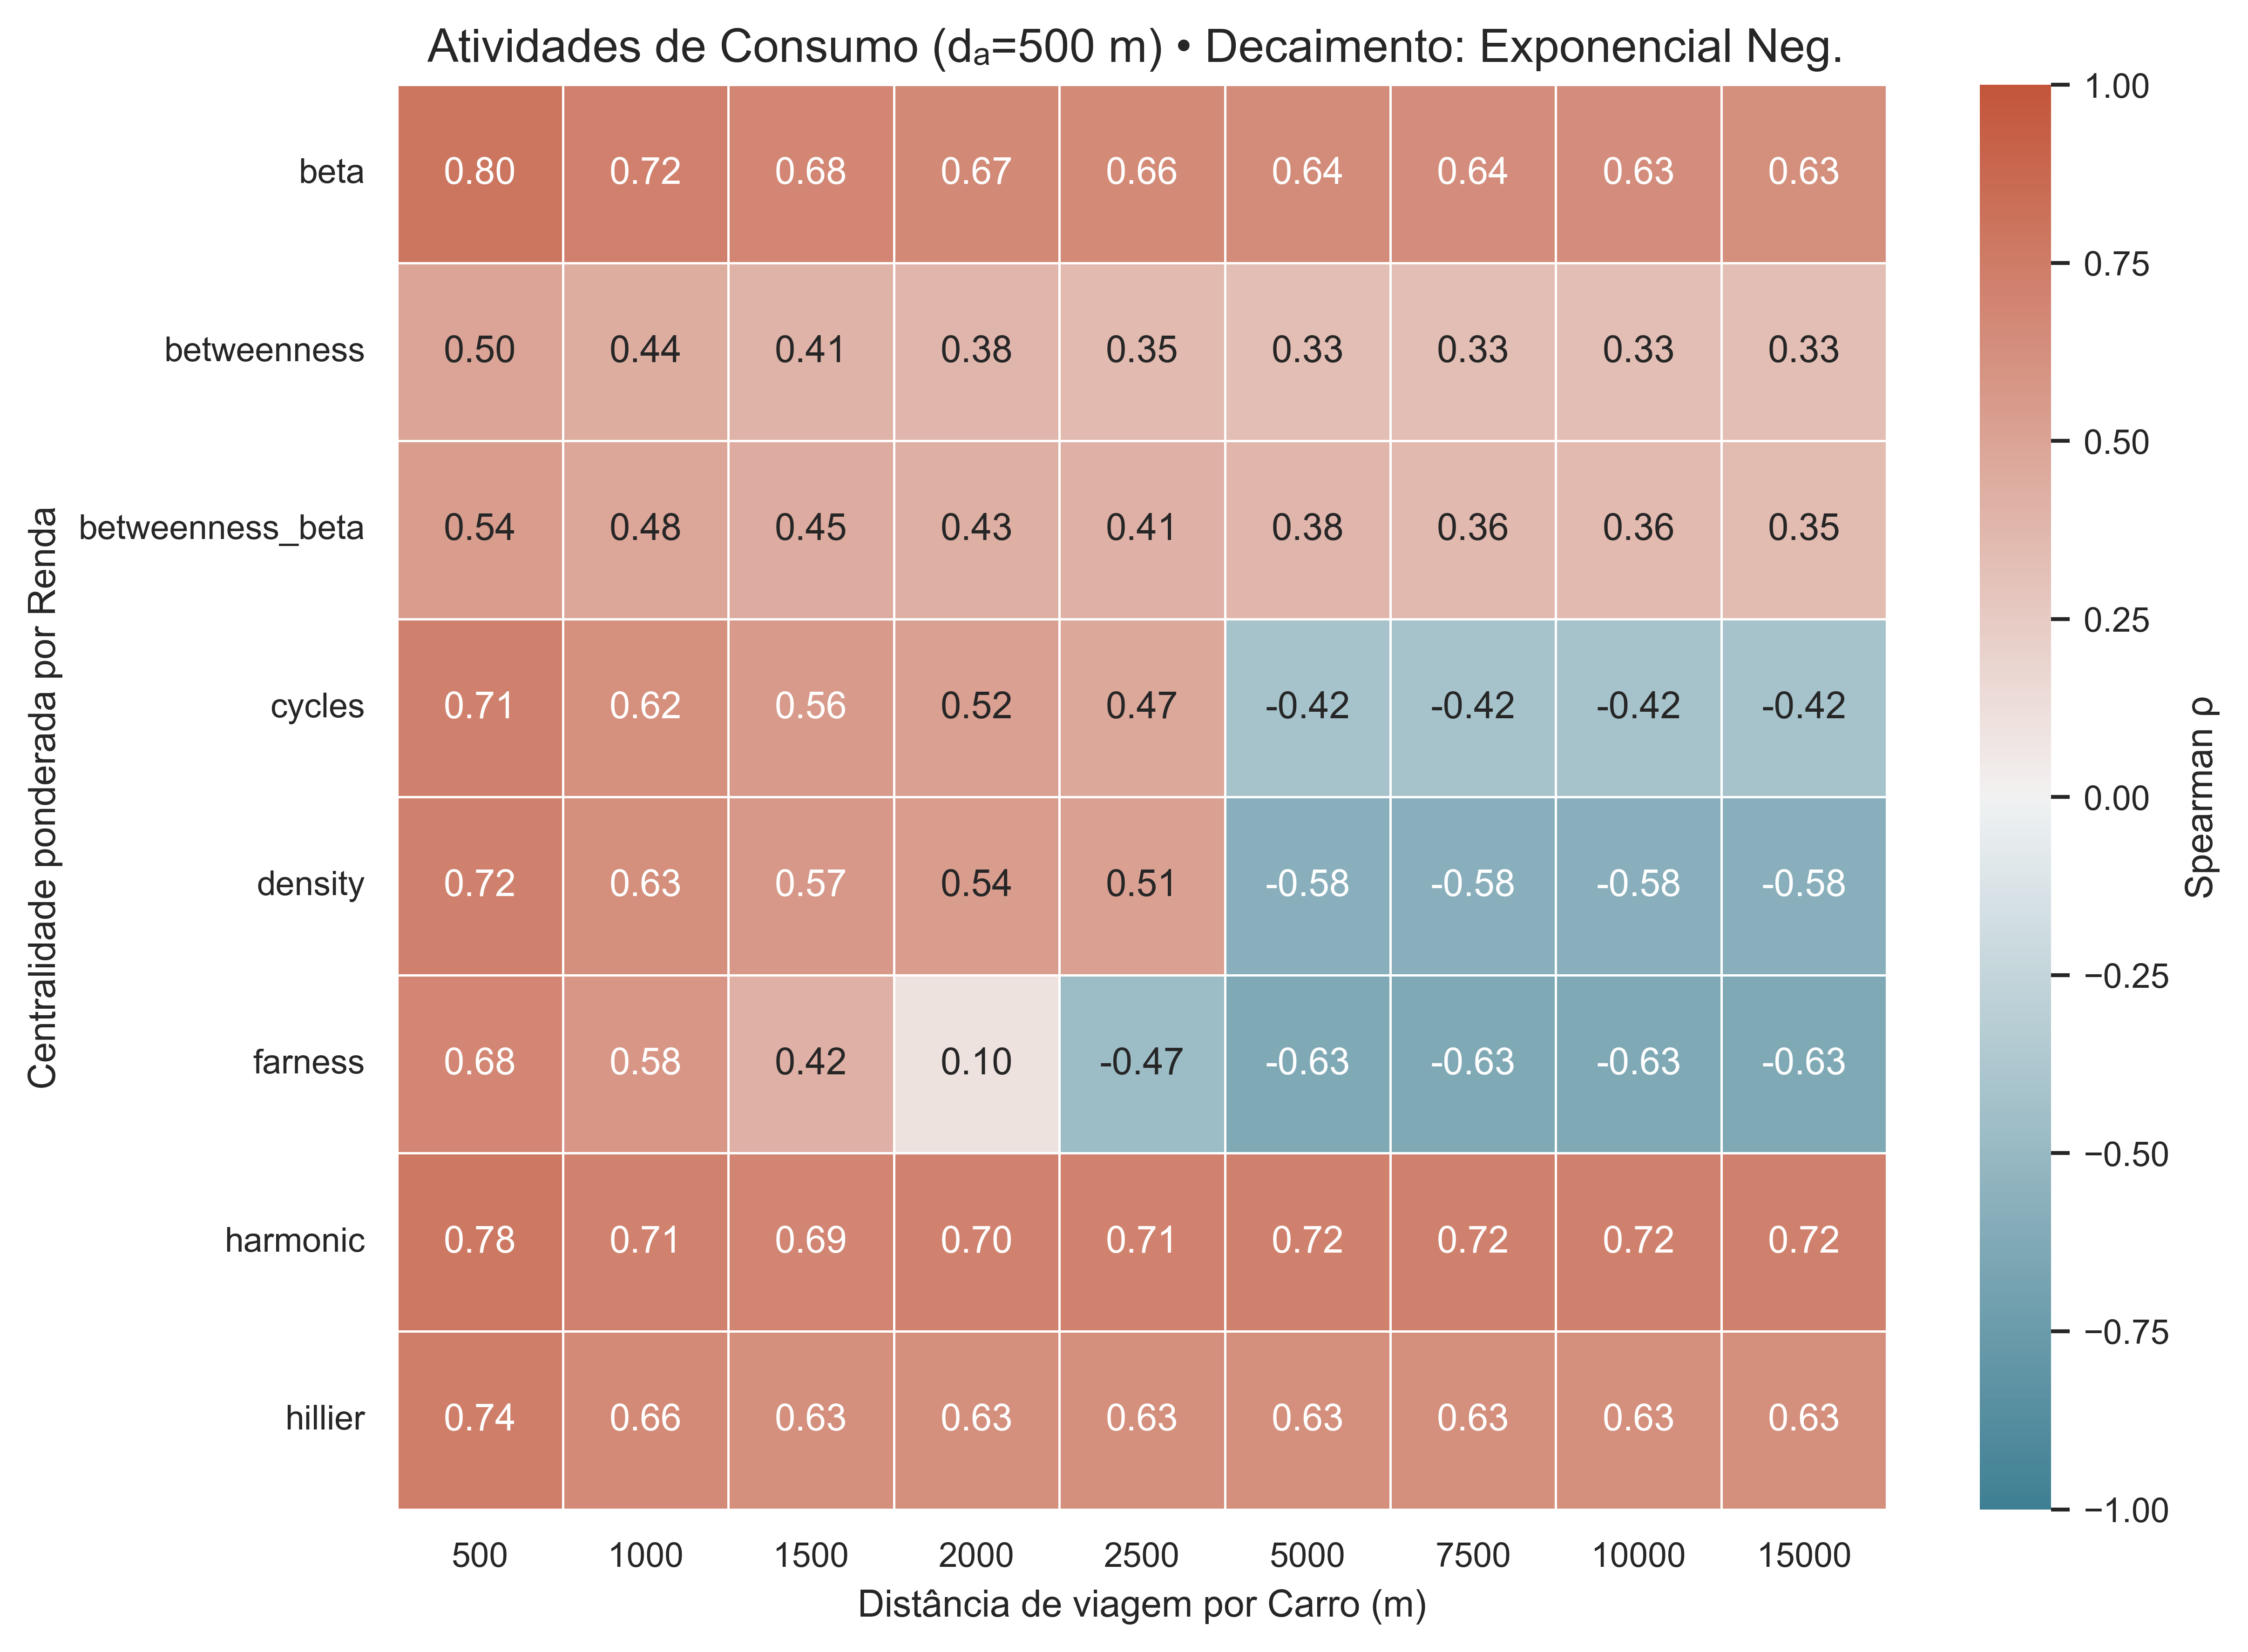

In [25]:
mode = 'private'
cent_weight = "income"

M = corr_matrix_vectorised(
    centralities, access,
    cent_weight=cent_weight, mode=mode, path="shortest",
    acc_weight="yes", acc_metric="accessibility", acc_radius=500
)

plot_heatmap(M,
            title=("Atividades de Consumo (dₐ=500 m) • Decaimento: Exponencial Neg. "),
            mode=mode,
            cent_weight=cent_weight,
            )
plt.show()

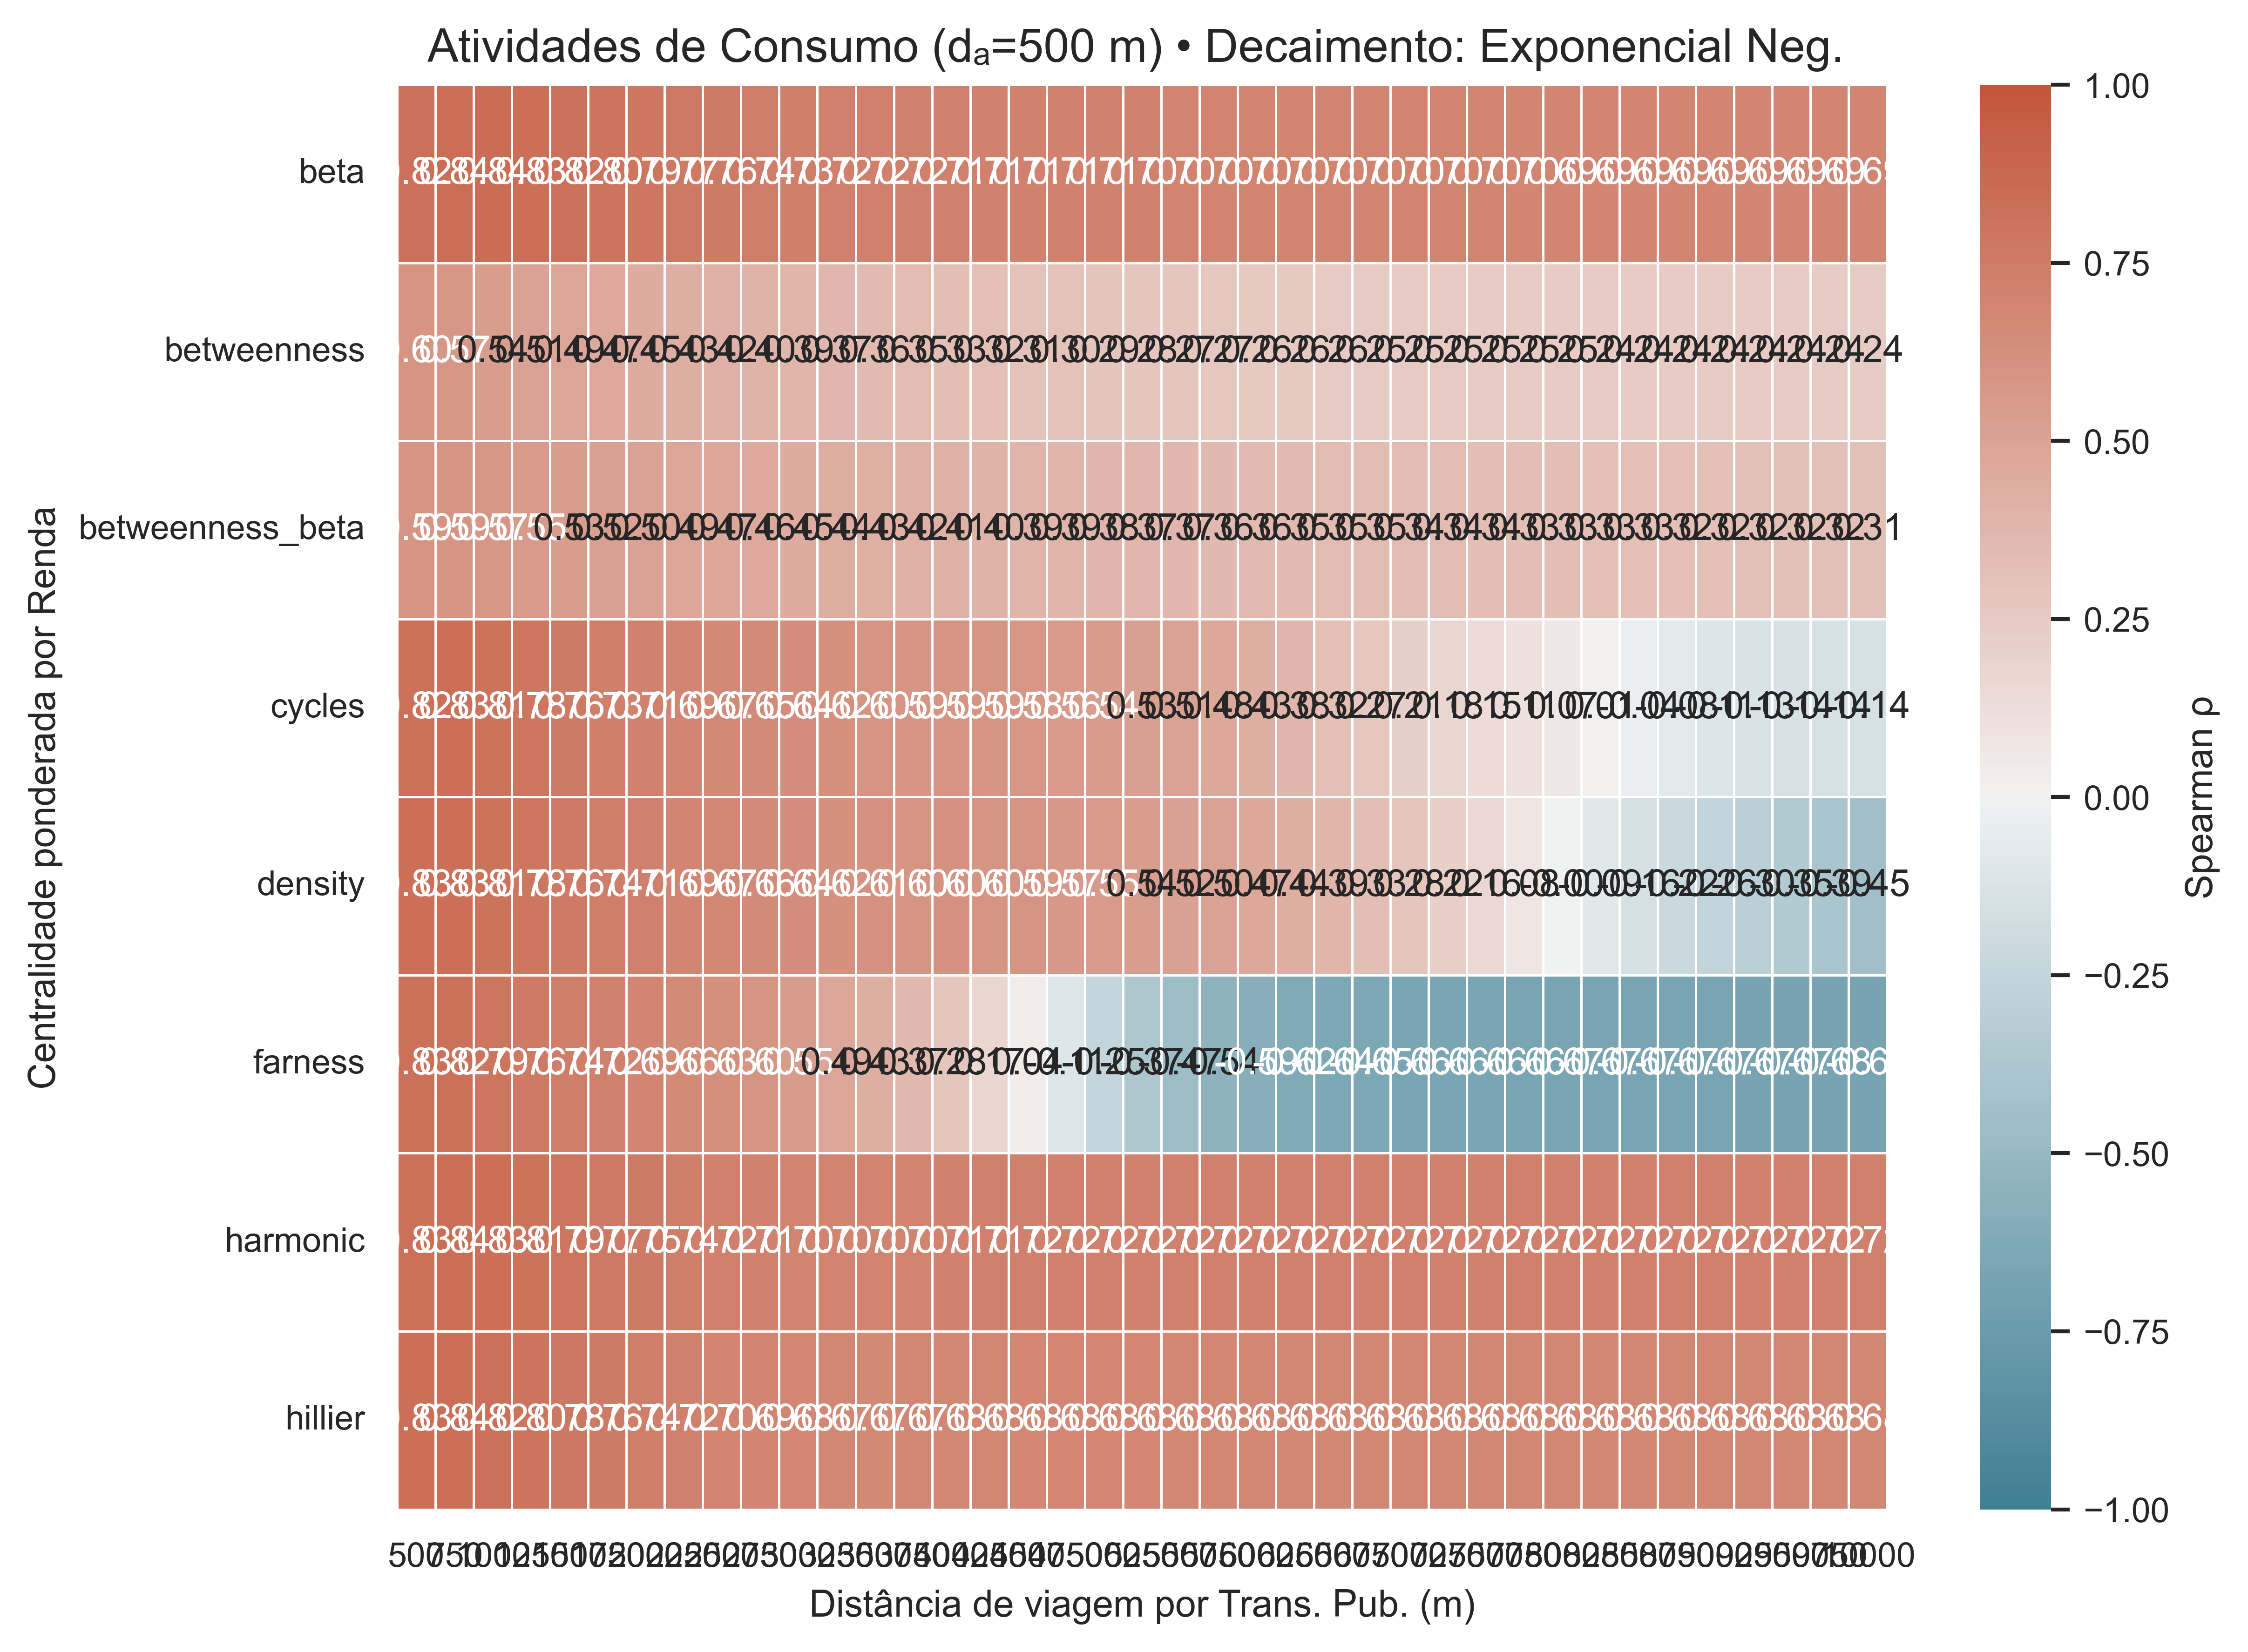

In [26]:
mode = 'public'
cent_weight = "income"

M = corr_matrix_vectorised(
    centralities, access,
    cent_weight=cent_weight, mode=mode, path="shortest",
    acc_weight="yes", acc_metric="accessibility", acc_radius=500
)

plot_heatmap(M,
            title=("Atividades de Consumo (dₐ=500 m) • Decaimento: Exponencial Neg. "),
            mode=mode,
            cent_weight=cent_weight,
            )
plt.show()

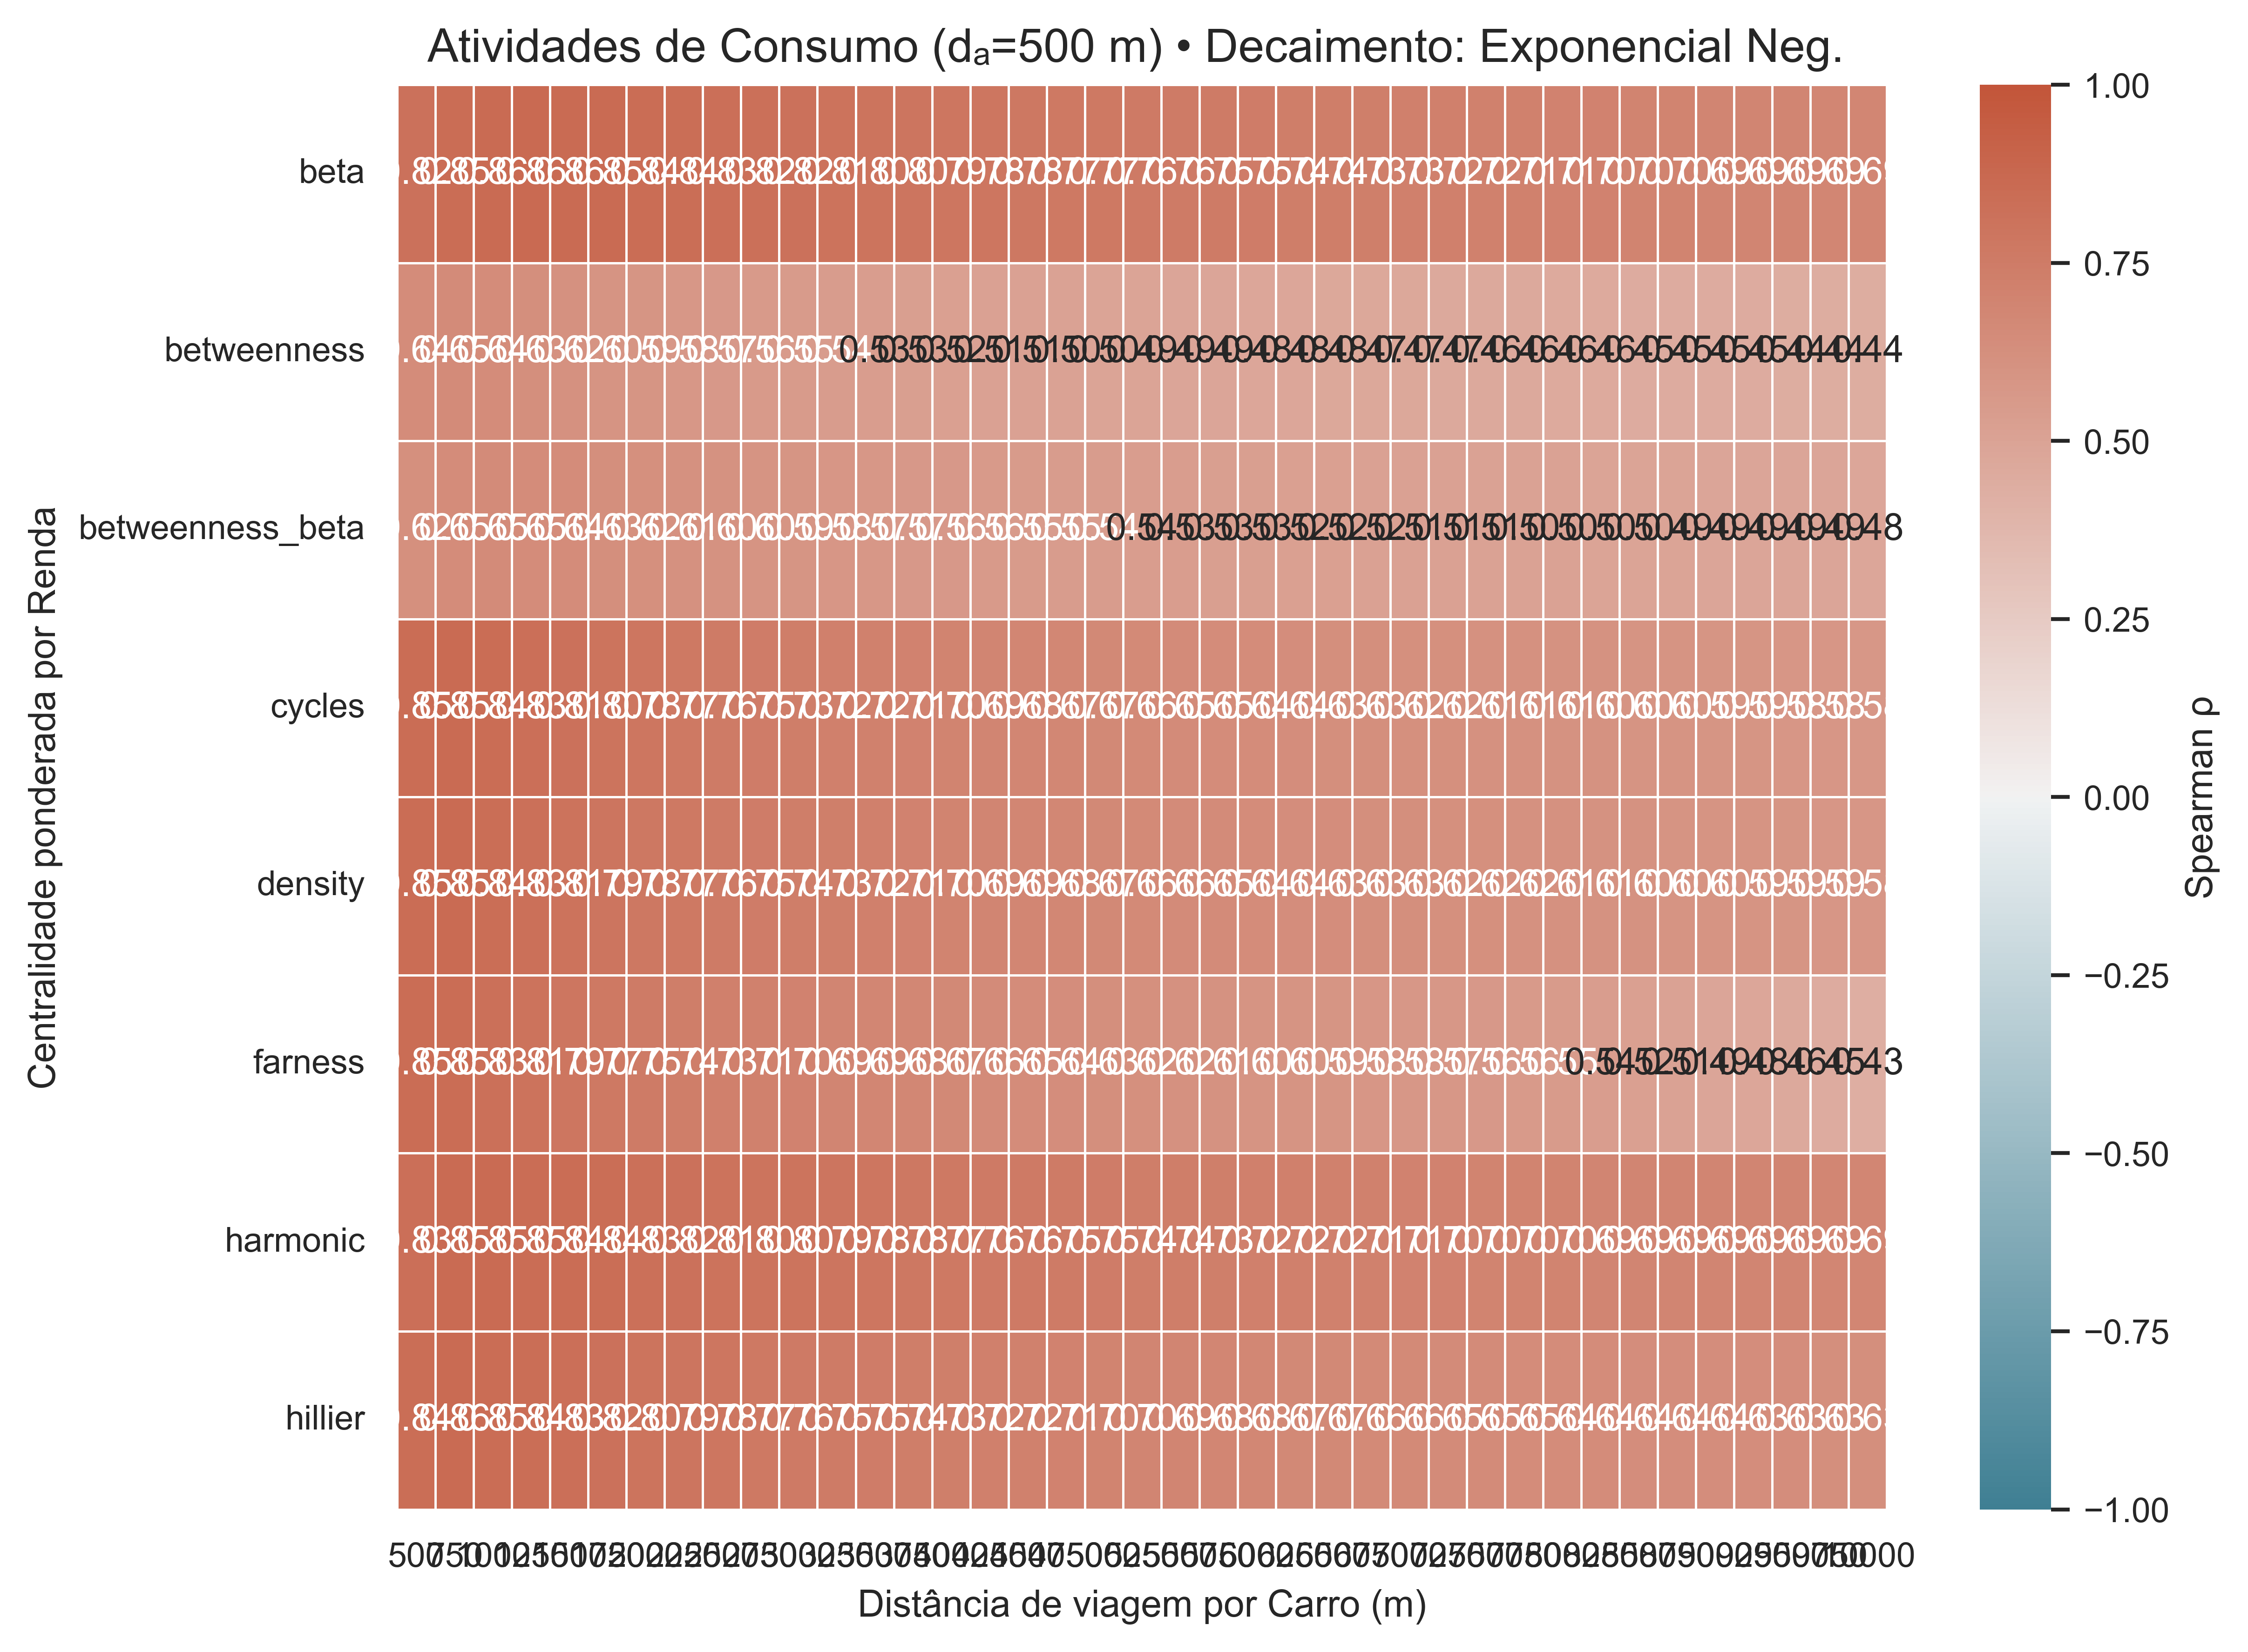

In [27]:
mode = 'walk'
cent_weight = "income"

M = corr_matrix_vectorised(
    centralities, access,
    cent_weight=cent_weight, mode=mode, path="shortest",
    acc_weight="yes", acc_metric="accessibility", acc_radius=500
)

plot_heatmap(M,
            title=("Atividades de Consumo (dₐ=500 m) • Decaimento: Exponencial Neg. "),
            mode=mode,
            cent_weight=cent_weight,
            )
plt.show()

In [60]:
centralities.xs(('income', 'public', 'shortest'), level=('weight', 'mode', 'path')).merge(
    access.xs(('yes', 500), level=('weight', 'radius')),
    left_index=True, right_index=True
).groupby('radius').corr(method='spearman').accessibility.unstack('radius')

radius,500,1000,1500,2000,2500,5000,7500,10000,15000
metric,,,,,,,,,
beta,0.81,0.83,0.81,0.77,0.74,0.70,0.69,0.68,0.68
betweenness,0.55,0.45,0.40,0.36,0.33,0.21,0.19,0.19,0.19
betweenness_beta,0.55,0.50,0.45,0.42,0.39,0.30,0.26,0.24,0.22
cycles,0.81,0.80,0.74,0.69,0.65,0.42,-0.07,-0.13,-0.13
density,0.82,0.80,0.75,0.69,0.65,0.42,-0.12,-0.58,-0.61
farness,0.82,0.78,0.72,0.66,0.58,-0.47,-0.66,-0.67,-0.67
harmonic,0.82,0.82,0.78,0.73,0.70,0.72,0.72,0.72,0.72
hillier,0.82,0.81,0.76,0.72,0.68,0.67,0.67,0.67,0.67
accessibility,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [61]:
centralities.xs(('households', 'public', 'shortest'), level=('weight', 'mode', 'path')).merge(
    access.xs(('yes', 500), level=('weight', 'radius')),
    left_index=True, right_index=True
).groupby('radius').corr(method='spearman').accessibility.unstack('radius')

radius,500,1000,1500,2000,2500,5000,7500,10000,15000
metric,,,,,,,,,
beta,0.53,0.66,0.71,0.74,0.74,0.71,0.69,0.68,0.67
betweenness,0.40,0.39,0.37,0.35,0.32,0.21,0.17,0.16,0.16
betweenness_beta,0.38,0.40,0.39,0.37,0.36,0.28,0.24,0.22,0.20
cycles,0.60,0.69,0.72,0.72,0.69,0.50,0.24,0.06,0.02
density,0.59,0.68,0.72,0.72,0.69,0.50,0.28,-0.04,-0.24
farness,0.60,0.68,0.71,0.71,0.66,0.09,-0.63,-0.64,-0.65
harmonic,0.56,0.68,0.72,0.74,0.73,0.71,0.72,0.72,0.72
hillier,0.58,0.68,0.72,0.73,0.71,0.65,0.65,0.65,0.65
accessibility,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


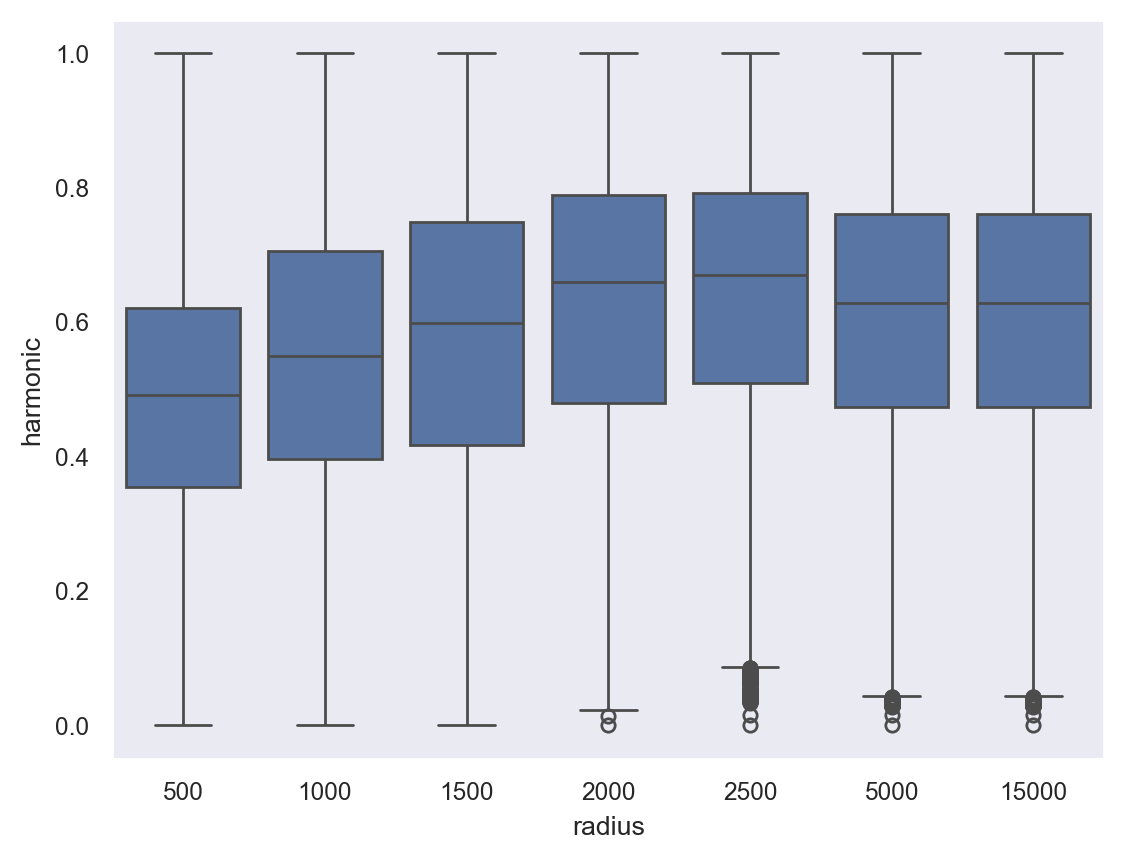

In [63]:
db = centralities.xs(('households', 'private', 'shortest'), level=('weight', 'mode', 'path')).reset_index(level='radius')
sns.boxplot(
    data=db,
    x='radius',
    y='harmonic',
)
plt.show()

In [45]:
centralities.isnull().sum()

metric
beta                0
betweenness         0
betweenness_beta    0
cycles              0
density             0
farness             0
harmonic            0
hillier             0
dtype: int64

In [43]:
nodes.select_dtypes("number").corr(method="spearman")

,x,y,habitantes,domicilios,massa_salarial_pessoas,massa_salarial_domicilios,estabelecimentos,weight
x,1.00,0.37,0.03,0.04,0.05,0.05,0.02,0.05
y,0.37,1.00,0.01,-0.00,-0.08,-0.09,-0.07,-0.08
habitantes,0.03,0.01,1.00,0.99,0.80,0.77,0.41,0.80
domicilios,0.04,-0.00,0.99,1.00,0.83,0.82,0.45,0.83
massa_salarial_pessoas,0.05,-0.08,0.80,0.83,1.00,0.99,0.59,1.00
massa_salarial_domicilios,0.05,-0.09,0.77,0.82,0.99,1.00,0.61,0.99
estabelecimentos,0.02,-0.07,0.41,0.45,0.59,0.61,1.00,0.59
weight,0.05,-0.08,0.80,0.83,1.00,0.99,0.59,1.00


In [38]:
pd.concat([x, y], axis='columns').corr(method='spearman')

,hill_q2,harmonic
hill_q2,1.00,0.57
harmonic,0.57,1.00


In [ ]:
# %%
# this is a relatively large dataset and may take a while to load
mad_gpd = gpd.read_file("./temp/dataset.gpkg")

# %%
images_path = pathlib.Path("./plots")
mad_gpd = common.rename_cent_cols(mad_gpd)

# %%
# generate
for is_angular, lu_cols in zip(
    [False, True], [common.LU_COLS_SHORTEST, common.LU_COLS_SIMPLEST], strict=False
):
    # create a copy of the dataframe with non variable cols removed
    mad_gpd_lu_filter = mad_gpd[lu_cols]
    ## Correlation Matrix
    corr = mad_gpd_lu_filter.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(11, 9), constrained_layout=True)
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    sns.heatmap(
        corr,
        ax=ax,
        mask=mask,
        cmap=cmap,
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.5},
    )
    ax.set_title("Correlation matrix" if is_angular is False else "Correlation matrix - angular")
    lu_corr_path = "lu_corr_matrix"
    if is_angular is True:
        lu_corr_path += "_ang"
    fig.savefig(images_path / f"{lu_corr_path}.pdf")

    ## PCA
    # extract 90% of explained variance
    n_components = 0.9
    # scale data
    stand_scaler = preprocessing.PowerTransformer()
    X_transf = stand_scaler.fit_transform(mad_gpd_lu_filter)
    model = PCA(n_components=4)
    X_latent = model.fit_transform(X_transf)
    exp_var = model.explained_variance_
    # eigenvector by eigenvalue - i.e. correlation to original
    loadings = model.components_.T * np.sqrt(exp_var)
    loadings = loadings.T  # transform for slicing
    for i in range(X_latent.shape[1]):
        vals = np.clip(X_latent[:, i], -10, 10)
        if is_angular is False:
            mad_gpd[f"pca_{i + 1}"] = vals
        else:
            mad_gpd[f"pca_{i + 1}_ang"] = vals
    print("explained variance ratio in %", model.explained_variance_ratio_ * 100)
    # plot PCA loadings
    fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharey=True, dpi=200, constrained_layout=True)
    lu_distances = [100, 200, 500, 1000, 2000]
    column_labels = [
        "food_bev",
        "retail",
        "services",
        "creat_entert",
        "accommod",
    ]
    # create heatmaps for original vectors plotted against PCA components
    for n in range(X_latent.shape[1]):
        heatmap_ax = axes[n]
        heatmap_ax.set_title(f"PCA {n + 1}" if is_angular is False else f"PCA {n + 1} - angular")
        heatmap_ax.set_yticks(np.arange(len(column_labels)))
        heatmap_ax.set_xticks(np.arange(len(lu_distances)))
        heatmap_corr = loadings[n].reshape(len(column_labels), len(lu_distances))
        sns.heatmap(
            heatmap_corr,
            ax=heatmap_ax,
            cmap="RdYlBu_r",
            vmin=-1,
            vmax=1,
            yticklabels=column_labels,
            xticklabels=lu_distances,
            cbar=False,
        )
        heatmap_ax.set_xticklabels(lu_distances, rotation=90, ha="right")
        heatmap_ax.set_xlabel(
            r"explained $\sigma^{2}$" + f" {model.explained_variance_ratio_[n]:.1%}"
        )
        # Add the correlation values on top
        for i, row in enumerate(heatmap_corr):
            for j, value in enumerate(row):
                heatmap_ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="black" if abs(value) < 0.5 else "white",
                    size=8,
                )
    pca_corr_path = "pca_corr_matrix"
    if is_angular is True:
        pca_corr_path += "_ang"
    fig.savefig(images_path / f"{pca_corr_path}.pdf")

# %%
lu_cols = ["pca_1", "cc_hill_q0_200_wt", "food_bev_200", "retail_200"]
lu_labels = [
    "PCA 1",
    "Landuse Richness 70m avg. walk dist. (200m max.)",
    "Food & Beverage 70m avg. walk dist. (200m max.)",
    "Retail 70m avg. walk dist. (200m max.)",
]
for col, label in zip(lu_cols, lu_labels, strict=False):
    fig, ax = plt.subplots(figsize=(8, 8), dpi=150, constrained_layout=True)
    mad_gpd.plot(
        ax=ax,
        column=col,
        cmap="turbo",
        linewidths=1.5,
        vmin=0,
        vmax=np.percentile(mad_gpd[col], 99),
        figsize=(6, 12),
    )
    ax.set_axis_off()
    ax.set_xlim(438000, 444400)
    ax.set_ylim(4472000, 4478400)
    ax.set_title(label)
    fig.savefig(images_path / f"map_{col}.png")

# %%
distances_cent = [500, 1000, 2000, 5000, 10000]
mad_gpd = common.generate_close_n_cols(mad_gpd, distances_cent, length_weighted=True)
mad_gpd = common.generate_close_n_cols(mad_gpd, distances_cent, length_weighted=False)
mad_gpd = mad_gpd.copy()  # fragmentation warnings

# %%
close_cols = common.generate_cent_columns(
    [
        "closeness_{d}",
        "close_N1_{d}",
        "close_N1.2_{d}",
        "close_N2_{d}",
        "harmonic_{d}",
    ],
    distances_cent,
)
# Generate labels for each distance
close_labels = []
for _pattern, label in [
    ("closeness", "Closeness"),
    ("close_N1", r"Normalised $N^{1}$"),
    ("close_N1.2", r"NAIN $N^{1.2}$"),
    ("close_N2", r"Improved $N^{2}$"),
    ("harmonic", "Harmonic"),
]:
    for d in distances_cent:
        close_labels.append(f"{label} {d}m")

# filter columns
mad_gpd_close_filter = mad_gpd[close_cols]
corr_close = mad_gpd_close_filter.corr()
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr_close,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    xticklabels=close_labels,
    yticklabels=close_labels,
)
ax.set_title("Correlation Matrix - Closeness Centrality Measures", pad=20)
fig.savefig(images_path / "cent_corr_matrix_close.pdf")

# %%
betw_cols = common.generate_cent_columns(
    [
        "betw_{d}",
        "betw_wt_{d}",
        "betw_{d}_ang",
        "NACH_{d}",
        "NACH_{d}_ang",
    ],
    distances_cent,
)
# Generate labels for each distance
betw_labels = []
for _pattern, label in [
    ("betw", "Betw."),
    ("betw_wt", "Wt Betw."),
    ("betw_ang", "Ang. Betw."),
    ("NACH", "NACH"),
    ("NACH_ang", "Ang. NACH"),
]:
    for d in distances_cent:
        betw_labels.append(f"{label} {d}m")

# filter columns
mad_gpd_betw_filter = mad_gpd[betw_cols]
corr_betw = mad_gpd_betw_filter.corr()
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr_betw,
    cmap=cmap,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.5},
    xticklabels=betw_labels,
    yticklabels=betw_labels,
)
ax.set_title("Correlation Matrix - Betweenness Centrality Measures", pad=20)
fig.savefig(images_path / "cent_corr_matrix_betw.pdf")

# %%
# plot correlations
cent_cols = common.generate_cent_columns(
    [
        "density_{d}",
        "far_{d}",
        "far_norm_{d}",
        "closeness_{d}",
        "close_N1_{d}",
        "close_N1.2_{d}",
        "close_N2_{d}",
        "harmonic_{d}",
        "gravity_{d}",
        "cycles_{d}",
        "betw_{d}",
        "betw_wt_{d}",
        "NACH_{d}",
    ],
    distances_cent,
)
cent_cols_ang = common.generate_cent_columns(
    [
        "far_{d}_ang",
        "far_norm_{d}_ang",
        "closeness_{d}_ang",
        "close_N1_{d}_ang",
        "close_N1.2_{d}_ang",
        "close_N2_{d}_ang",
        "harmonic_{d}_ang",
        "betw_{d}_ang",
        "NACH_{d}_ang",
    ],
    distances_cent,
)
lw_cent_cols = common.generate_cent_columns(
    [
        "lw_density_{d}",
        "density_{d}_seg",
        "lw_far_{d}",
        "lw_far_norm_{d}",
        "lw_closeness_{d}",
        "lw_close_N1_{d}",
        "lw_close_N1.2_{d}",
        "lw_close_N2_{d}",
        "lw_harmonic_{d}",
        "harmonic_{d}_seg",
        "lw_gravity_{d}",
        "gravity_{d}_seg",
        "lw_betw_{d}",
        "lw_betw_wt_{d}",
        "betw_{d}_seg",
        "lw_NACH_{d}",
    ],
    distances_cent,
)
lw_cent_cols_ang = common.generate_cent_columns(
    [
        "lw_far_{d}_ang",
        "lw_far_norm_{d}_ang",
        "lw_closeness_{d}_ang",
        "lw_close_N1_{d}_ang",
        "lw_close_N1.2_{d}_ang",
        "lw_close_N2_{d}_ang",
        "lw_harmonic_{d}_ang",
        "lw_betw_{d}_ang",
        "lw_NACH_{d}_ang",
    ],
    distances_cent,
)

# %%
cent_labels = [
    "Density",
    "Farness",
    "Farness N",
    r"Closeness",
    r"Closeness $N^{1}$",
    r"NAIN $N^{1.2}$",
    r"Improved $N^{2}$",
    "Harmonic",
    "Gravity",
    "Cycles",
    "Between.",
    "wt. Between.",
    "NACH",
]
cent_labels_ang = [
    "ang. Farness",
    "ang. Farness N",
    r"ang. Closeness",
    r"ang. Closeness $N^{1}$",
    r"ang. NAIN $N^{1.2}$",
    r"ang. Improved $N^{2}$",
    "ang. Harmonic",
    "ang. Between.",
    "ang. NACH",
]
lw_cent_labels = [
    "Density",
    "Density cont.",
    "Farness",
    "Farness N",
    "Closeness",
    r"Closeness $N^{1}$",
    r"NAIN $N^{1.2}$",
    r"Improved $N^{2}$",
    "Harmonic",
    "Harmonic cont.",
    "Gravity",
    "Gravity cont.",
    "Between.",
    "wt. Between.",
    "Between. cont.",
    "NACH",
]
lw_cent_labels_ang = [
    "ang. Farness",
    "ang. Farness N",
    "ang. Closeness",
    r"ang. Closeness $N^{1}$",
    r"ang. NAIN $N^{1.2}$",
    r"ang. Improved $N^{2}$",
    "ang. Harmonic",
    "ang. Between.",
    "ang. NACH",
]

# %%
# distances: [100, 200, 500]
# betas: [0.03999999910593033, 0.019999999552965164, 0.00800000037997961]
# avg dist: [35.11949157714844, 70.23898315429688, 175.59747314453125]
for cols, corr_labels, suptitle, cent_lu_corr_path, c_cols, c_labels in [
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - centrality",
        "cent_lu_corrs.pdf",
        cent_cols,
        cent_labels,
    ],
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - length weighted centrality",
        "cent_lu_corrs_length_wtd.pdf",
        lw_cent_cols,
        lw_cent_labels,
    ],
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - angular centrality",
        "cent_lu_corrs_ang.pdf",
        cent_cols_ang,
        cent_labels_ang,
    ],
    [
        ("pca_1", "food_bev_200", "retail_200"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - length weighted angular centrality",
        "cent_lu_corrs_length_wtd_ang.pdf",
        lw_cent_cols_ang,
        lw_cent_labels_ang,
    ],
    [
        ("pca_1_ang", "food_bev_200_ang", "retail_200_ang"),
        (
            "PCA 1",
            r"Food/Bev $\mu=70m$ / $d_{max}=200$",
            r"Retail $\mu=70m$ / $d_{max}=200$",
        ),
        "Spearman Rank - centrality (geometric lu. dist.)",
        "cent_lu_corrs_pca_geometric.pdf",
        cent_cols,
        cent_labels,
    ],
]:
    mad_gpd_cent_filter = mad_gpd[c_cols]
    # create heatmaps for original variables plotted against correlations

    heatmap_height = len(c_labels) * 0.55
    fig, axes = plt.subplots(
        1, 3, figsize=(8, heatmap_height), sharey=True, dpi=200, constrained_layout=True
    )
    fig.suptitle(suptitle, fontsize=14)

    for col, corr_label, heatmap_ax in zip(cols, corr_labels, axes, strict=True):
        corr = mad_gpd_cent_filter.corrwith(mad_gpd[col], method="spearman", numeric_only=True)
        heatmap_ax.set_title(corr_label)
        heatmap_corr = corr.values.reshape(len(c_labels), len(distances_cent))
        # set this before the plot otherwise ticks are off centre
        heatmap_ax.set_xticks(np.arange(len(distances_cent)))
        heatmap_ax.set_yticks(np.arange(len(c_labels)))
        sns.heatmap(
            heatmap_corr,
            ax=heatmap_ax,
            cmap="RdYlBu_r",
            vmin=-1,
            vmax=1,
            yticklabels=c_labels,
            xticklabels=distances_cent,
            cbar=False,
            square=True,
        )
        heatmap_ax.set_xticklabels(distances_cent, rotation=90, ha="center")
        heatmap_ax.set_yticklabels(c_labels, va="center")
        # Add the correlation values on top
        for i, row in enumerate(heatmap_corr):
            for j, value in enumerate(row):
                heatmap_ax.text(
                    j + 0.5,
                    i + 0.5,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="black" if abs(value) < 0.5 else "white",
                    size=8,
                )
    fig.savefig(images_path / cent_lu_corr_path, bbox_inches="tight")

# %%
bw_log_1000 = "betw_wt_1000_log"
mad_gpd[bw_log_1000] = np.log(mad_gpd["betw_wt_1000"] + 1)

fig, axes = plt.subplots(2, 2, sharey=True, figsize=(8, 8))
sns.kdeplot(
    ax=axes[0][0],
    data=mad_gpd,
    x=bw_log_1000,
    y="pca_1",
)
axes[0][0].set_xlabel(r"Log distance weighted betweenness $d_{\max}=1000m$")
axes[0][0].set_ylabel(r"PCA 1 - Landuses")

sns.kdeplot(
    ax=axes[0][1],
    data=mad_gpd,
    x="close_N2_1000",
    y="pca_1",
    kind="kde",
)
axes[0][1].set_xlabel(r"Improved Closeness $N^{2}$ $d_{\max}=1000m$")

bw_log_5000 = "betw_wt_5000_log"
mad_gpd[bw_log_5000] = np.log(mad_gpd["betw_wt_5000"] + 1)

sns.kdeplot(
    ax=axes[1][0],
    data=mad_gpd,
    x=bw_log_5000,
    y="pca_1",
)
axes[1][0].set_xlabel(r"Log distance weighted betweenness $d_{\max}=5000m$")
axes[1][0].set_ylabel(r"PCA 1 - Landuses")

sns.kdeplot(
    ax=axes[1][1],
    data=mad_gpd,
    x="close_N2_5000",
    y="pca_1",
    kind="kde",
)
axes[1][1].set_xlabel(r"Improved Closeness $N^{2}$ $d_{\max}=5000m$")

plt.tight_layout()
plt.savefig(images_path / "closen_vs_betw_vs_mixed.pdf")

mad_gpd.drop(columns=[bw_log_1000], inplace=True)
mad_gpd.drop(columns=[bw_log_5000], inplace=True)

# %%
ax = mad_gpd.plot(
    column="close_N2_1000",
    cmap="Reds",
    linewidth=1,
    # vmin=0,
    # vmax=1,
)
ax.set_axis_off()
ax.set_xlim(438000, 444400)
ax.set_ylim(4472000, 4478400)

ax = mad_gpd.plot(
    column="harmonic_1000",
    cmap="Reds",
    linewidth=1,
    # vmin=0,
    # vmax=1,
)
ax.set_axis_off()
ax.set_xlim(438000, 444400)
ax.set_ylim(4472000, 4478400)

# %%
for is_angular in [False, True]:
    fig, axes = plt.subplots(3, 2, figsize=(8, 12), dpi=150, constrained_layout=True)
    # Iterate over the subplot axes
    for n, (col, label) in enumerate(
        [
            ("closeness_{d}", r"Closeness"),
            ("close_N2_{d}", r"Closeness $N^{2}$ - Improved"),
            ("close_N1_{d}", r"Closeness $N^{1}$ - Normalised"),
            ("harmonic_{d}", "Harmonic"),
            ("close_N1.2_{d}", r"Closeness $N^{1.2}$ - NAIN"),
            ("gravity_{d}", "Gravity"),
        ]
    ):
        target_col = col.format(d=1000)
        col_temp = f"{target_col}_plot_temp"
        title = f"1000m {label}"
        row_n = n // 2
        col_n = n % 2
        if is_angular is True:
            target_col += "_ang"
            title += " - angular"
        if "gravity" in target_col and is_angular is True:
            axes[row_n][col_n].axis("off")
        else:
            vals = mad_gpd[target_col]
            vals.fillna(0, inplace=True)
            vals -= np.nanmin(vals)
            vals = np.clip(vals, 0, np.nanpercentile(vals, 99))
            # enhance contrast
            vals = vals**1.5
            vals /= np.nanmax(vals)
            vals = 0.2 + vals * 0.8
            mad_gpd[col_temp] = vals
            ax = mad_gpd.plot(
                ax=axes[row_n][col_n],
                column=col_temp,
                cmap="Reds",
                linewidth=vals,
                vmin=0,
                vmax=1,
            )
            axes[row_n][col_n].set_title(title)
            axes[row_n][col_n].set_axis_off()
            axes[row_n][col_n].set_xlim(438000, 444400)
            axes[row_n][col_n].set_ylim(4472000, 4478400)
            cx.add_basemap(
                ax, crs=mad_gpd.crs.to_epsg(), source=cx.providers.CartoDB.PositronNoLabels
            )
            ax.add_artist(NorthArrow(location="upper right", scale=0.25, rotation={"degrees": 0}))
            ax.add_artist(
                scalebar.ScaleBar(1, units="m", length_fraction=0.25, location="lower right")
            )
            mad_gpd.drop(columns=[col_temp], inplace=True)

    if is_angular is False:
        # Save the figure
        fig.savefig(images_path / "closeness_compare.png")
    else:
        # Save the figure
        fig.savefig(images_path / "closeness_compare_ang.png")

# %%
fig, axes = plt.subplots(3, 2, figsize=(8, 12), dpi=150, constrained_layout=True)
for col_n, (col, label) in enumerate(
    [("betw_{d}", "Betweenness"), ("betw_{d}_ang", "Betweenness - angular")]
):
    for row_n, dist in enumerate([1000, 5000, 10000]):
        target_col = col.format(d=dist)
        vals = mad_gpd[target_col]
        vals.fillna(0, inplace=True)
        vals -= np.nanmin(vals)
        vals = np.clip(vals, 0, np.nanpercentile(vals, 98))
        vals /= np.nanmax(vals)
        vals = 0.2 + vals * 0.8
        col_temp = f"{target_col}_plot_temp"
        mad_gpd[col_temp] = vals
        ax = mad_gpd.plot(
            ax=axes[row_n][col_n],
            column=col_temp,
            cmap="Reds",
            linewidth=vals,
            vmin=0,
            vmax=1,
        )
        axes[row_n][col_n].set_title(f"{label} {int(dist / 1000)}km")
        axes[row_n][col_n].set_axis_off()
        axes[row_n][col_n].set_xlim(438000, 444400)
        axes[row_n][col_n].set_ylim(4472000, 4478400)
        cx.add_basemap(ax, crs=mad_gpd.crs.to_epsg(), source=cx.providers.CartoDB.PositronNoLabels)
        ax.add_artist(NorthArrow(location="upper right", scale=0.25, rotation={"degrees": 0}))
        ax.add_artist(scalebar.ScaleBar(1, units="m", length_fraction=0.25, location="lower right"))
        mad_gpd.drop(columns=[col_temp], inplace=True)

    fig.savefig(images_path / "betweenness_compare.png")